# Fabre Museum Project: Observational Data Analysis
by Amelie Goube

## 1. Nettoyage des donnees et exportation d'un fichier pour les futures analyses sur python et R

In [7]:
# ==========================================
# Fabre Museum Project
# Nettoyage des données
# Objectif :
# analyser l’exploration spatiale,
# l’engagement moteur
# et les interactions sociales
# ==========================================

import pandas as pd

# ------------------------------------------
# 1. Charger les données
# ------------------------------------------

df = pd.read_csv(
    "data/data_observation.csv",
    sep=';'
)

# ------------------------------------------
# 2. Nettoyer les noms de colonnes
# ------------------------------------------

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("é", "e")
    .str.replace("è", "e")
    .str.replace("œ", "oe")
)

# Supprimer les doubles underscores
df.columns = df.columns.str.replace("__", "_")

# ------------------------------------------
# 3. Nettoyage des valeurs manquantes
# ------------------------------------------

# Remplacer "NA" et cellules vides par NaN
df = df.replace("NA", pd.NA)
df = df.replace("", pd.NA)

# Supprimer les lignes totalement vides
df = df.dropna(how='all')

# ------------------------------------------
# 4. Sélection des variables utiles
# ------------------------------------------
# Variables pertinentes pour :
# - exploration spatiale
# - engagement moteur
# - interactions sociales
# ------------------------------------------

variables = [
    'children_id',
    'sex',
    'number_of_zones_explored',
    'overall_motor_engagement',
    'interaction_with_peers',
    'movement_autonomy',
    'interaction_with_environment'
]

df = df[variables]

# ------------------------------------------
# 5. Vérification des données
# ------------------------------------------

print("\nInformations générales :")
print(df.info())

print("\nAperçu des données :")
print(df.head())

print("\nValeurs manquantes :")
print(df.isna().sum())

# ------------------------------------------
# 6. Export des données nettoyées
# ------------------------------------------

df.to_csv(
    "data/data_clean.csv",
    sep=';',
    index=False
)

print("\nFichier exporté : data_clean.csv")


Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   children_id                   10 non-null     str    
 1   sex                           10 non-null     str    
 2   number_of_zones_explored      8 non-null      float64
 3   overall_motor_engagement      10 non-null     int64  
 4   interaction_with_peers        10 non-null     int64  
 5   movement_autonomy             10 non-null     int64  
 6   interaction_with_environment  10 non-null     int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 692.0 bytes
None

Aperçu des données :
  children_id sex  number_of_zones_explored  overall_motor_engagement  \
0      obs1_f   f                       8.0                         0   
1      obs1_g   g                       8.0                         1   
2      obs2_f   f                       0.0 

## 2. Importation des donnees nettoyées pour l'exploration visuelle

In [2]:

import pandas as pd
data = pd.read_csv(
    "data/data_clean.csv",
    sep=';'
)
print(data)

  children_id sex  number_of_zones_explored  overall_motor_engagement  \
0      obs1_f   f                       8.0                         0   
1      obs1_g   g                       8.0                         1   
2      obs2_f   f                       0.0                         2   
3      obs2_g   g                       0.0                         1   
4      obs3_f   f                       4.0                         1   
5      obs3_g   g                       4.0                         1   
6      obs4_f   f                       NaN                         1   
7      obs4_g   g                       NaN                         1   
8      obs5_f   f                       9.0                         1   
9      obs5_g   g                       9.0                         2   

   interaction_with_peers  movement_autonomy  interaction_with_environment  
0                       1                  0                             2  
1                       1                 

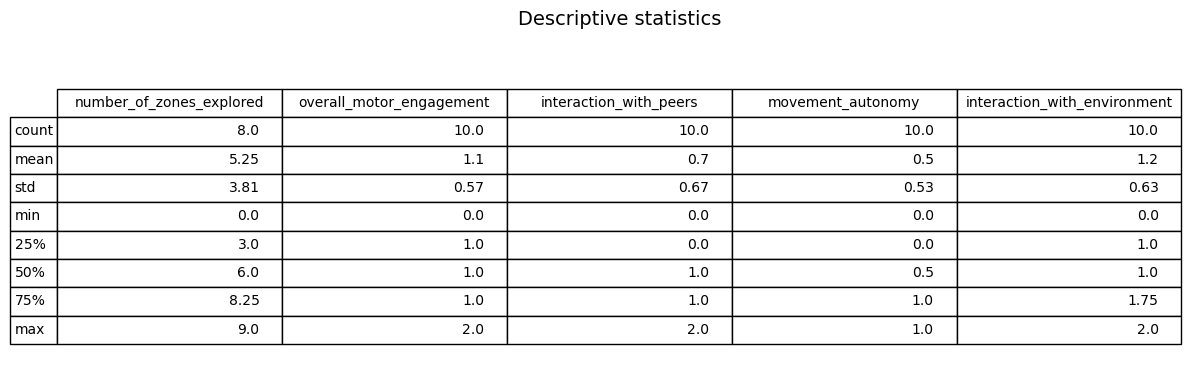

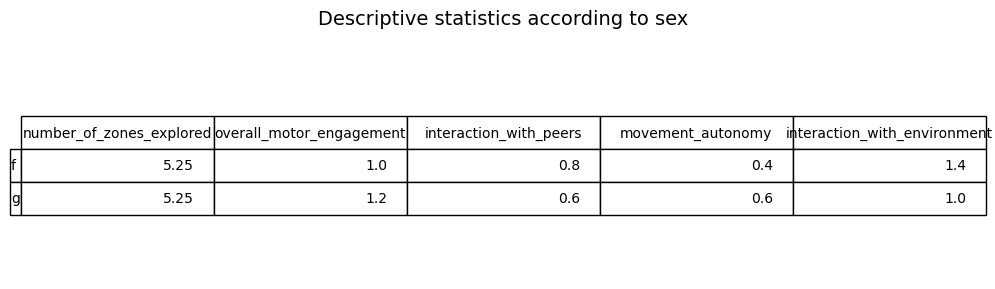

In [6]:
import matplotlib.pyplot as plt
# ==========================================
# 2. Tableau descriptif général
# ==========================================

desc = data.describe().round(2)

# Supprimer children_id si présent
desc = desc.drop(columns=['children_id'], errors='ignore')

# ------------------------------------------
# Création figure
# ------------------------------------------

fig, ax = plt.subplots(figsize=(12,4))

ax.axis('off')

table = ax.table(
    cellText=desc.values,
    colLabels=desc.columns,
    rowLabels=desc.index,
    loc='center'
)

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

plt.title(
    "Descriptive statistics",
    fontsize=14,
    pad=20
)

plt.tight_layout()

# Sauvegarde
plt.savefig(
    "descriptive_statistics.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ==========================================
# 3. Tableau descriptif selon le sexe
# ==========================================

desc_sex = data.groupby('sex').mean(
    numeric_only=True
).round(2)

# ------------------------------------------
# Création figure
# ------------------------------------------

fig, ax = plt.subplots(figsize=(10,3))

ax.axis('off')

table = ax.table(
    cellText=desc_sex.values,
    colLabels=desc_sex.columns,
    rowLabels=desc_sex.index,
    loc='center'
)

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

plt.title(
    "Descriptive statistics according to sex",
    fontsize=14,
    pad=20
)

plt.tight_layout()

# Sauvegarde
plt.savefig(
    "descriptive_statistics_sex.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Interprétation du tableau descriptif général
Le premier tableau présente une vue d’ensemble des comportements observés chez les enfants pendant la visite du musée.
Les résultats montrent une variabilité importante dans l’exploration spatiale. En moyenne, les enfants ont exploré 5.25 zones du musée, avec des valeurs allant de 0 à 9 zones. L’écart-type relativement élevé (3.81) indique que certains enfants ont très peu exploré l’espace alors que d’autres ont montré une exploration beaucoup plus importante.
L’engagement moteur global apparaît relativement faible et homogène dans l’échantillon (moyenne = 1.1 ; écart-type = 0.57), suggérant que les comportements moteurs observés restent globalement modérés entre les enfants.
Les interactions avec les pairs présentent une moyenne de 0.7, ce qui indique un niveau d’interactions sociales relativement limité mais présent durant les observations.
Concernant l’autonomie motrice, la moyenne est de 0.5, traduisant une variabilité entre les enfants dans leur manière de se déplacer et d’explorer l’espace de façon autonome.
Enfin, les interactions avec l’environnement muséal montrent une moyenne de 1.2, suggérant que les enfants interagissent régulièrement avec l’espace et les éléments du musée pendant la visite.

### Interprétation du tableau descriptif selon le sexe
Le second tableau compare les comportements observés entre les filles et les garçons.
Les résultats montrent que le nombre moyen de zones explorées est identique chez les filles et les garçons (5.25), suggérant un niveau d’exploration spatiale similaire entre les deux groupes.
En revanche, les garçons présentent un engagement moteur légèrement plus élevé (1.2 contre 1.0 chez les filles), ce qui peut indiquer une activité corporelle un peu plus importante durant la visite.
Les filles montrent davantage d’interactions avec les pairs (0.8 contre 0.6 chez les garçons), suggérant une tendance à des comportements sociaux légèrement plus fréquents.
Concernant l’autonomie motrice, les garçons obtiennent une moyenne plus élevée (0.6 contre 0.4 chez les filles), ce qui pourrait refléter une plus grande autonomie dans les déplacements observés.
Enfin, les filles présentent davantage d’interactions avec l’environnement muséal (1.4 contre 1.0 chez les garçons), indiquant une implication potentiellement plus importante avec les éléments présents dans l’espace du musée.
Cependant, ces différences doivent être interprétées avec prudence en raison du faible effectif de l’échantillon et du caractère exploratoire de l’étude.

                              number_of_zones_explored  \
number_of_zones_explored                          1.00   
overall_motor_engagement                         -0.25   
interaction_with_peers                            0.83   
movement_autonomy                                -0.74   
interaction_with_environment                      0.08   

                              overall_motor_engagement  \
number_of_zones_explored                         -0.25   
overall_motor_engagement                          1.00   
interaction_with_peers                           -0.20   
movement_autonomy                                 0.19   
interaction_with_environment                     -0.06   

                              interaction_with_peers  movement_autonomy  \
number_of_zones_explored                        0.83              -0.74   
overall_motor_engagement                       -0.20               0.19   
interaction_with_peers                          1.00              -0.16   
mo

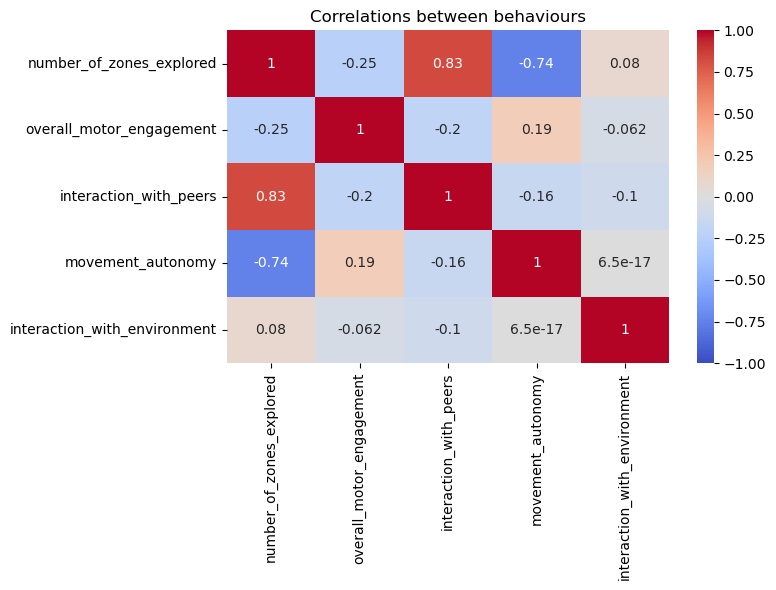

In [7]:
# ==========================================
# Corrélations entre comportements
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Variables numériques
corr = data.corr(numeric_only=True)

# Afficher les valeurs
print(corr.round(2))

# ------------------------------------------
# Heatmap
# ------------------------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Correlations between behaviours")

plt.tight_layout()

plt.savefig(
    "correlation_heatmap.png",
    dpi=300
)

plt.show()

Interprétation synthétique niveau M2

Les résultats montrent plusieurs relations intéressantes entre les comportements observés.

La corrélation la plus forte concerne le nombre de zones explorées et les interactions avec les pairs :

r=0.83

Cette forte corrélation positive suggère que les enfants qui explorent davantage l’espace muséal interagissent également plus fréquemment avec les autres enfants. Ce résultat semble indiquer que l’exploration spatiale s’accompagne d’une dynamique sociale plus importante pendant la visite.

Une forte corrélation négative est également observée entre le nombre de zones explorées et l’autonomie motrice :

r=−0.74

L’interprétation de cette relation dépend du codage de la variable d’autonomie. Si les faibles valeurs correspondent à une plus grande autonomie, ce résultat pourrait signifier que les enfants les plus autonomes explorent davantage l’espace du musée.

En revanche, les relations entre l’exploration spatiale et l’engagement moteur apparaissent faibles :

r=−0.25

Cela suggère que le fait d’explorer davantage le musée n’est pas nécessairement associé à un engagement corporel plus important dans cet échantillon.

Enfin, les interactions avec l’environnement muséal présentent des corrélations très faibles avec les autres variables observées, indiquant que cette dimension semble relativement indépendante des autres comportements étudiés.